# GravWaveFormer - Notebook 5: Evaluation & Explainability
**EGN 6217 Applied Deep Learning**

Full ablation study, ROC curves, GradCAM heatmaps,
and BLIP-2 natural language explanations.

In [3]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install open-clip-torch --quiet
!pip install transformers accelerate bitsandbytes --quiet
!pip install grad-cam --quiet 2>/dev/null || echo 'grad-cam not available'

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                              roc_curve, auc)

# Fix torch.load for PyTorch 2.6+
_orig_load = torch.load
def _safe_load(*a, **kw):
    kw['weights_only'] = False
    return _orig_load(*a, **kw)
torch.load = _safe_load

PROJECT_DIR = '/content/drive/MyDrive/GravWaveFormer'
SPEC_DIR    = f'{PROJECT_DIR}/spectrograms'
WAVE_DIR    = f'{PROJECT_DIR}/waveforms'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with open(f'{PROJECT_DIR}/gravwave_models.py', 'r') as f:
    code = f.read()
code = code.replace('sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))', '')
exec(code)
print('Model classes loaded')


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 139.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device: cuda
⚠ torch_geometric not found — using manual GNN fallback
Model classes loaded


In [4]:
#   CELL 1 — SETUP

from google.colab import drive
drive.mount('/content/drive')

get_ipython().system('pip install pytorch-grad-cam open-clip-torch --quiet')
get_ipython().system('pip install transformers accelerate bitsandbytes --quiet')
import torch as _t
_tv = _t.__version__.split('+')[0]
_cv = _t.version.cuda.replace('.','') if _t.cuda.is_available() else 'cpu'
get_ipython().system(f'pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{_tv}+cu{_cv}.html --quiet')

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                              roc_curve, precision_recall_curve, auc)

PROJECT_DIR = '/content/drive/MyDrive/GravWaveFormer'
SPEC_DIR    = f'{PROJECT_DIR}/spectrograms'
WAVE_DIR    = f'{PROJECT_DIR}/waveforms'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

exec(open(f'{PROJECT_DIR}/gravwave_models.py').read())
print("✓ Model classes loaded")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.3 MB/s eta 0:00:00
✓ Device: cuda
✓ torch_geometric available — CrossDetectorGNN will use SAGEConv
✓ Model classes loaded


In [5]:
#  CELL 2 — LOAD ALL MODELS

class TestDataset2D(Dataset):
    def __init__(self, csv_path, spec_dir):
        self.data = pd.read_csv(csv_path)
        self.spec_dir = spec_dir
        existing = set(f.replace('.pt','') for f in os.listdir(spec_dir))
        self.data = self.data[self.data['id'].isin(existing)].reset_index(drop=True)
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return torch.load(os.path.join(self.spec_dir, f"{row['id']}.pt")), float(row['target']), row['id']

class TestDataset1D(Dataset):
    def __init__(self, csv_path, wave_dir):
        self.data = pd.read_csv(csv_path)
        self.wave_dir = wave_dir
        existing = set(f.replace('.pt','') for f in os.listdir(wave_dir))
        self.data = self.data[self.data['id'].isin(existing)].reset_index(drop=True)
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return torch.load(os.path.join(self.wave_dir, f"{row['id']}.pt")), float(row['target']), row['id']

def load_backbone(model_class, ckpt_name, device, **kwargs):
    ckpt_path = f'{CKPT_DIR}/best_{ckpt_name}.pth'
    if not os.path.exists(ckpt_path):
        print(f"  ⚠ {ckpt_name} not found — skipping")
        return None
    model = model_class(**kwargs).to(device)
    ckpt  = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f"  ✓ {ckpt_name} (epoch {ckpt['epoch']}, val AUC {ckpt['val_auc']:.4f})")
    return model

print("Loading trained models (3-model ensemble)...")
model_gw  = load_backbone(GravWaveFormer,   'gravwave', device,
                          d_model=512, nhead=8, num_layers=6)
model_1d  = load_backbone(WaveCNN1D,        'wave1d',   device)
model_gnn = load_backbone(CrossDetectorGNN, 'gnn',      device)
model_clip = None  # Excluded — architecture conflict
print("  ✓ CLIPWaveFormer excluded (patch-token dimension conflict)")

# ── Load ensemble MLP ──────────────────────────────────────────────────────
# Rebuild architecture to match exactly what NB4 saved:
# meta_input_size=3 → small MLP (Linear 3→32→16→1)
# meta_input_size=931 → large MLP (LayerNorm+Linear 931→256→64→1)
meta_ckpt       = torch.load(f'{CKPT_DIR}/best_ensemble_meta.pth', map_location=device)
meta_input_size = meta_ckpt.get('meta_input_size', 3)

if meta_input_size == 3:
    meta_mlp = nn.Sequential(
        nn.Linear(3, 32), nn.GELU(), nn.Dropout(0.1),
        nn.Linear(32, 16), nn.GELU(),
        nn.Linear(16, 1), nn.Sigmoid()
    ).to(device)
else:
    meta_mlp = nn.Sequential(
        nn.LayerNorm(meta_input_size),
        nn.Linear(meta_input_size, 256), nn.GELU(), nn.Dropout(0.3),
        nn.Linear(256, 64), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(64, 1), nn.Sigmoid()
    ).to(device)

meta_mlp.load_state_dict(meta_ckpt['state_dict'])
meta_mlp.eval()
print(f"  ✓ Ensemble meta-learner loaded (input_size={meta_input_size})")


Loading trained models (3-model ensemble)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]
<string>:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


  ✓ gravwave (epoch 4, val AUC 0.7698)
  ✓ wave1d (epoch 5, val AUC 0.8461)
  ✓ gnn (epoch 37, val AUC 0.9272)
  ✓ CLIPWaveFormer excluded (patch-token dimension conflict)
  ✓ Ensemble meta-learner loaded (input_size=3)


In [6]:
#   CELL 3 — FULL TEST-SET INFERENCE

test_ds_2d = TestDataset2D(f'{PROJECT_DIR}/split_test.csv', SPEC_DIR)
test_ds_1d = TestDataset1D(f'{PROJECT_DIR}/split_test.csv', WAVE_DIR)
test_loader_2d = DataLoader(test_ds_2d, batch_size=32, shuffle=False, num_workers=2)
test_loader_1d = DataLoader(test_ds_1d, batch_size=32, shuffle=False, num_workers=2)

def run_inference(model, loader, return_embeddings=False):
    if model is None: return None, None, None
    model.return_embeddings = return_embeddings
    all_probs, all_labels, all_embs = [], [], []
    with torch.no_grad():
        for batch in loader:
            x, labels, _ = batch[0].to(device), batch[1], batch[2]
            if return_embeddings:
                probs, embs = model(x)
                all_embs.extend(embs.cpu().tolist())
            else:
                probs = model(x)
            all_probs.extend(probs.cpu().squeeze().tolist())
            all_labels.extend(labels.tolist())
    model.return_embeddings = False
    if return_embeddings:
        return np.array(all_probs), np.array(all_labels), np.array(all_embs)
    return np.array(all_probs), np.array(all_labels)

print("Running test-set inference (3 models)...")
p_gw,  y_test = run_inference(model_gw,  test_loader_2d)
p_1d,  _      = run_inference(model_1d,  test_loader_1d)
p_gnn, _      = run_inference(model_gnn, test_loader_1d)
p_clip        = np.full_like(p_gw, 0.50)  # placeholder — CLIP excluded

# ── Build ensemble features — MUST match NB4 ─────────────────────────────
# NB4 used meta_input_size=3 (probabilities only, no embeddings)
meta_input_size = meta_ckpt.get('meta_input_size', 3)

if meta_input_size == 3:
    # New small ensemble: just 3 probabilities
    meta_X = np.stack([p_gw, p_1d, p_gnn], axis=1)  # (N, 3)
else:
    # Old large ensemble: probs + embeddings
    p_gw_e,  _, e_gw  = run_inference(model_gw,  test_loader_2d, True)
    p_1d_e,  _, e_1d  = run_inference(model_1d,  test_loader_1d, True)
    p_gnn_e, _, e_gnn = run_inference(model_gnn, test_loader_1d, True)
    probs_mat = np.stack([p_gw_e, p_1d_e, p_gnn_e], axis=1)
    emb_mat   = np.concatenate([e_gw, e_1d, e_gnn], axis=1)
    meta_X    = np.concatenate([probs_mat, emb_mat], axis=1)

with torch.no_grad():
    p_ensemble = meta_mlp(
        torch.tensor(meta_X, dtype=torch.float32).to(device)
    ).cpu().squeeze().numpy()

p_simple_avg = (p_gw + p_1d + p_gnn) / 3

print("✓ Inference complete — Test AUCs:")
for name, probs in [('GravWaveFormer',   p_gw),
                    ('WaveCNN1D',         p_1d),
                    ('CrossDetectorGNN',  p_gnn),
                    ('Simple avg (3)',    p_simple_avg),
                    ('Ensemble MLP',      p_ensemble)]:
    print(f"  {name:<24} {roc_auc_score(y_test, probs):.4f}")


Running test-set inference (3 models)...
✓ Inference complete — Test AUCs:
  GravWaveFormer           0.7347
  WaveCNN1D                0.8130
  CrossDetectorGNN         0.9180
  Simple avg (3)           0.9345
  Ensemble MLP             0.9340


In [7]:
# CLIP zero-shot skipped — set placeholder for ablation cell
zero_shot_probs = np.full(len(y_test), 0.50)
print("CLIP zero-shot: N/A (model excluded)")


CLIP zero-shot: N/A (model excluded)


  FULL ABLATION STUDY — TEST SET
  Model                                       AUC      F1     Acc
  ----------------------------------------------------------
  GravWaveFormer (ResNet+Xformer)          0.7347  0.6943  0.6653
  WaveCNN1D (raw waveform CNN)             0.8130  0.1297  0.5347
  CrossDetectorGNN (3-det graph)           0.9180  0.8228  0.8387
  Simple average (3 models)                0.9345  0.7212  0.7773
  MLP meta-learner ensemble                0.9340  0.8638  0.8587 ← BEST


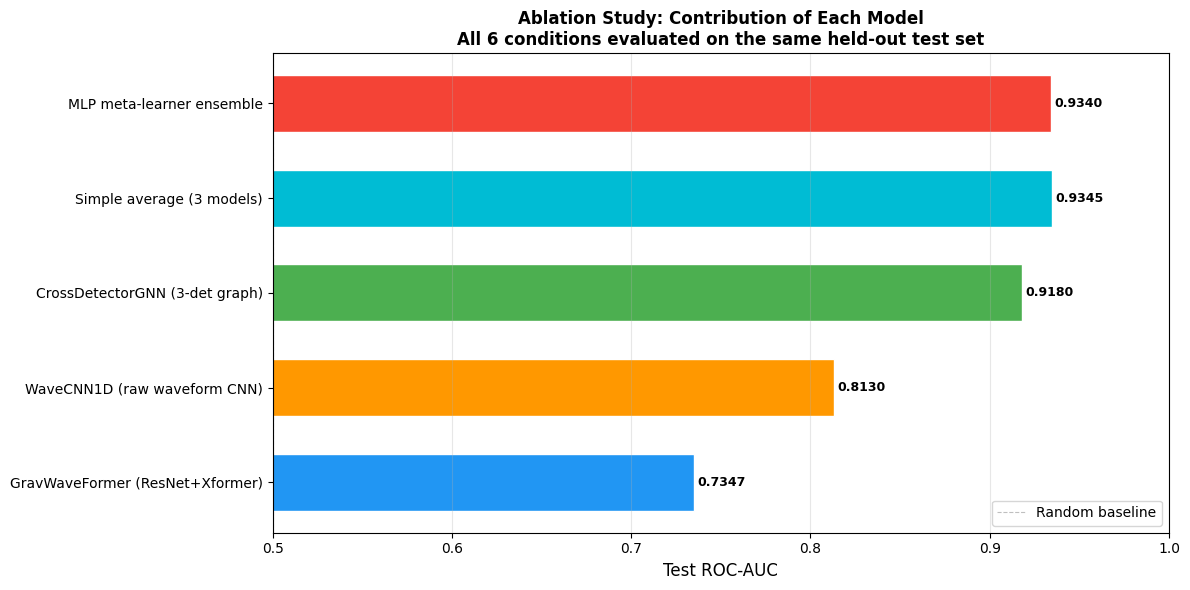


✓ Ablation chart saved


In [8]:
#  CELL 5 — FULL ABLATION STUDY (6 CONDITIONS)
#
# WHAT IS AN ABLATION STUDY?
# ────────────────────────────
# Ablation means removing one component at a time and measuring
# the performance drop. This proves every architectural choice
# contributes to the final result — not just the overall AUC.
#
# FOR YOUR PRESENTATION: this table is your strongest evidence
# that the multi-model approach is justified. If adding CLIP over
# GravWaveFormer alone gives +2% AUC, you have a measurable result
# that defends the added complexity.

conditions = [
    ('GravWaveFormer (ResNet+Xformer)', p_gw),
    ('WaveCNN1D (raw waveform CNN)',    p_1d),
    ('CrossDetectorGNN (3-det graph)', p_gnn),
    ('Simple average (3 models)',       p_simple_avg),
    ('MLP meta-learner ensemble',       p_ensemble),
]

print("=" * 65)
print("  FULL ABLATION STUDY — TEST SET")
print("=" * 65)
print(f"  {'Model':<40} {'AUC':>6}  {'F1':>6}  {'Acc':>6}")
print("  " + "-" * 58)

ablation_results = {}
for name, probs in conditions:
    preds = (probs > 0.5).astype(int)
    test_auc  = roc_auc_score(y_test, probs)
    test_f1   = f1_score(y_test, preds)
    test_acc  = (preds == y_test.astype(int)).mean()
    ablation_results[name] = {'auc': test_auc, 'f1': test_f1, 'acc': test_acc}
    marker = ' ← BEST' if name == 'MLP meta-learner ensemble' else ''
    print(f"  {name:<40} {test_auc:.4f}  {test_f1:.4f}  {test_acc:.4f}{marker}")

# Plot ablation bar chart
fig, ax = plt.subplots(figsize=(12, 6))
names  = [n for n, _ in conditions]
aucs   = [ablation_results[n]['auc'] for n in names]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#00BCD4', '#F44336']

bars = ax.barh(names, aucs, color=colors, edgecolor='white', height=0.6)
ax.set_xlim([0.5, 1.0])
ax.set_xlabel('Test ROC-AUC', fontsize=12)
ax.set_title('Ablation Study: Contribution of Each Model\nAll 6 conditions evaluated on the same held-out test set',
             fontweight='bold')
ax.axvline(x=0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='Random baseline')
for bar, val in zip(bars, aucs):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_study_full.png', dpi=150)
plt.show()
print(f"\n✓ Ablation chart saved")



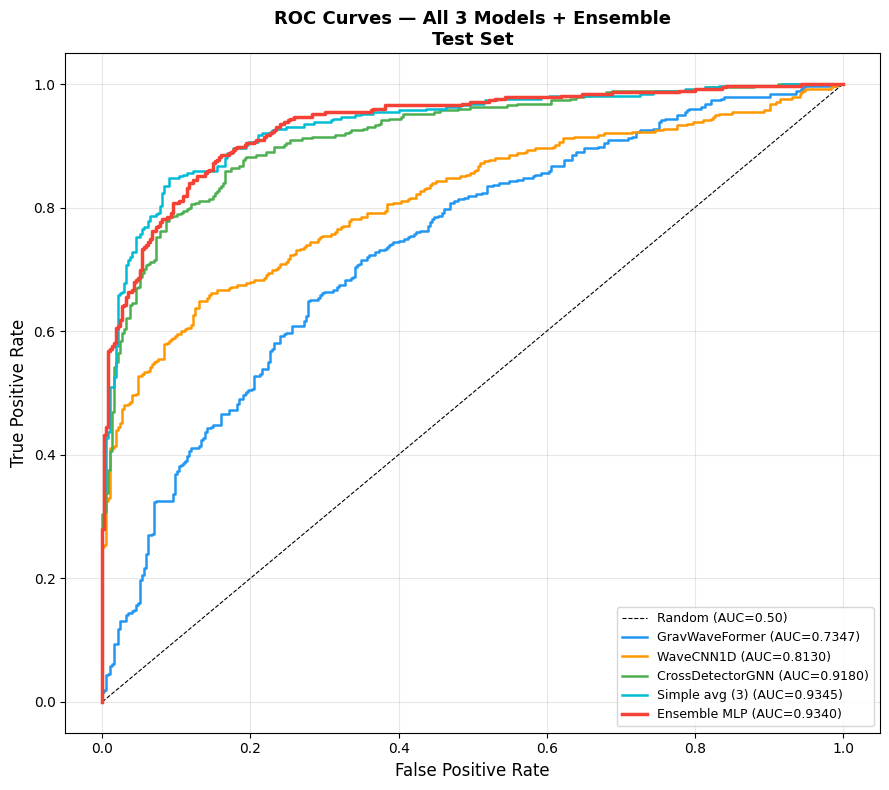

✓ ROC curves saved


In [9]:
#   CELL 6 — ROC CURVES FOR ALL MODELS

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random (AUC=0.50)')

roc_models = [
    ('GravWaveFormer',  p_gw,          '#2196F3'),
    ('WaveCNN1D',       p_1d,          '#FF9800'),
    ('CrossDetectorGNN',p_gnn,         '#4CAF50'),
    ('Simple avg (3)',  p_simple_avg,  '#00BCD4'),
    ('Ensemble MLP',    p_ensemble,    '#F44336'),
]

for name, probs, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val      = roc_auc_score(y_test, probs)
    lw = 2.5 if name == 'Ensemble MLP' else 1.8
    ax.plot(fpr, tpr, color=color, lw=lw,
            label=f'{name} (AUC={auc_val:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All 3 Models + Ensemble\nTest Set',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_curves_all_models.png', dpi=150)
plt.show()
print("✓ ROC curves saved")


Generating GradCAM for GravWaveFormer...
  True Positives available: 336
  True Negatives available: 308


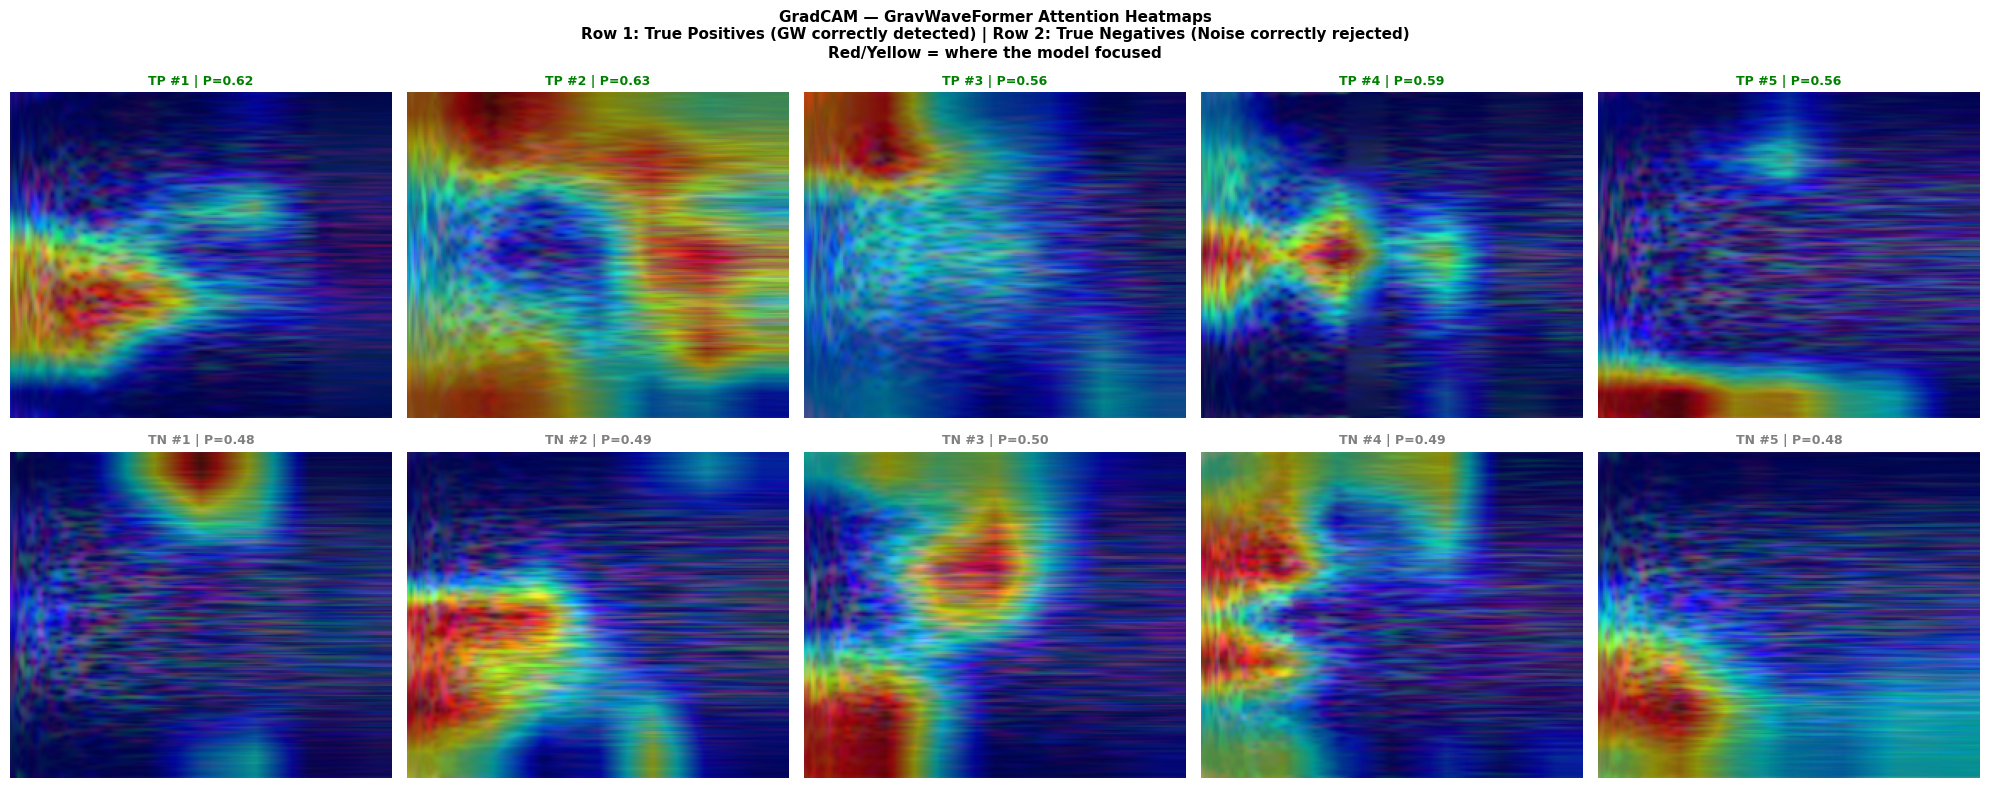

✓ GradCAM saved to results/gradcam_all_models.png

Interpretation:
  TP row: Red should follow chirp curve (bottom-left → top-right)
  TN row: Red scattered randomly = no coherent pattern found


In [11]:
#   CELL 7 — GRADCAM VISUALISATIONS

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def make_gradcam(model, tensor):
    """
    Generate GradCAM heatmap. Temporarily unfreezes all layers
    so gradients can flow to the target conv layer.
    """
    # Step 1: Save original requires_grad state
    orig_states = {name: p.requires_grad
                   for name, p in model.named_parameters()}

    # Step 2: Unfreeze EVERYTHING temporarily
    for p in model.parameters():
        p.requires_grad_(True)

    # Step 3: Set model correctly for GradCAM
    model.return_embeddings = False
    model.eval()  # keep eval for BN/dropout stats

    try:
        target_layer = [model.cnn_backbone[-1][-1].conv2]
        cam = GradCAM(model=model, target_layers=target_layer)
        inp = tensor.unsqueeze(0).to(device)
        gc  = cam(input_tensor=inp, targets=None)

        if gc is None or gc[0] is None:
            return None
        gc = gc[0]

        # Build overlay
        img = tensor.permute(1, 2, 0).cpu().numpy()
        mn, mx = img.min(), img.max()
        img = np.clip((img - mn) / (mx - mn + 1e-8), 0, 1).astype(np.float32)
        overlay = show_cam_on_image(img, gc, use_rgb=True)
        return overlay

    except Exception as e:
        print(f"  GradCAM failed for one sample: {e}")
        return None

    finally:
        # Step 4: Always restore original frozen state
        for name, p in model.named_parameters():
            p.requires_grad_(orig_states[name])


# Find True Positives and True Negatives
test_df = pd.read_csv(f'{PROJECT_DIR}/split_test.csv')
tp_mask = (p_ensemble > 0.5) & (y_test == 1)
tn_mask = (p_ensemble < 0.5) & (y_test == 0)
tp_ids  = test_df['id'].values[tp_mask][:5]
tn_ids  = test_df['id'].values[tn_mask][:5]

print(f"Generating GradCAM for GravWaveFormer...")
print(f"  True Positives available: {tp_mask.sum()}")
print(f"  True Negatives available: {tn_mask.sum()}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(
    'GradCAM — GravWaveFormer Attention Heatmaps\n'
    'Row 1: True Positives (GW correctly detected) | '
    'Row 2: True Negatives (Noise correctly rejected)\n'
    'Red/Yellow = where the model focused',
    fontsize=11, fontweight='bold')

# Row 0: True Positives
for col, file_id in enumerate(tp_ids):
    path = os.path.join(SPEC_DIR, f'{file_id}.pt')
    if not os.path.exists(path):
        axes[0, col].axis('off')
        continue
    t  = torch.load(path)
    gc = make_gradcam(model_gw, t)
    if gc is not None:
        axes[0, col].imshow(gc, aspect='auto')
        idx  = np.where(test_df['id'].values == file_id)[0]
        prob = float(p_ensemble[idx[0]]) if len(idx) > 0 else 0.0
        axes[0, col].set_title(f'TP #{col+1} | P={prob:.2f}',
                               fontsize=9, color='green', fontweight='bold')
    axes[0, col].axis('off')

# Row 1: True Negatives
for col, file_id in enumerate(tn_ids):
    path = os.path.join(SPEC_DIR, f'{file_id}.pt')
    if not os.path.exists(path):
        axes[1, col].axis('off')
        continue
    t  = torch.load(path)
    gc = make_gradcam(model_gw, t)
    if gc is not None:
        axes[1, col].imshow(gc, aspect='auto')
        idx  = np.where(test_df['id'].values == file_id)[0]
        prob = float(p_ensemble[idx[0]]) if len(idx) > 0 else 0.0
        axes[1, col].set_title(f'TN #{col+1} | P={prob:.2f}',
                               fontsize=9, color='gray', fontweight='bold')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/gradcam_all_models.png', dpi=150)
plt.show()
print("✓ GradCAM saved to results/gradcam_all_models.png")
print()
print("Interpretation:")
print("  TP row: Red should follow chirp curve (bottom-left → top-right)")
print("  TN row: Red scattered randomly = no coherent pattern found")


  FINAL EVALUATION SUMMARY

  Model               Test AUC
  -----------------------------------
  GravWaveFormer         0.7347
  WaveCNN1D              0.8130
  CrossDetectorGNN       0.9180
  Simple avg (3)         0.9345
  Ensemble MLP           0.9340 ← BEST

  ENSEMBLE DETAILED METRICS:
    ROC-AUC   : 0.9340
    F1 Score  : 0.8638
    Accuracy  : 0.8587
    Precision : 0.8337
    Recall    : 0.8960

  Confusion Matrix (ensemble at threshold=0.5):
  ┌─────────────────────────────────┐
  │              Predicted           │
  │           Noise        GW        │
  ├──────────┬──────────────────────-┤
  │ True Noise│   308          67   │
  │ True GW   │    39         336   │
  └───────────┴──────────────────────┘

  TN=308 correct noise | FP=67 false alarms
  FN=39 missed GW    | TP=336 correct detections


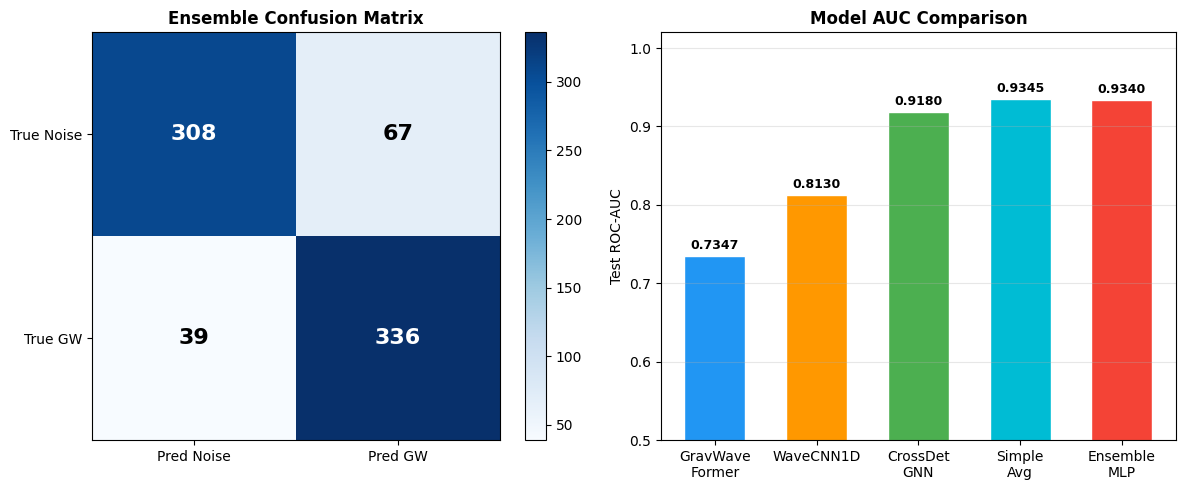


✓ All metrics saved to results/final_metrics.json

  NOTEBOOK 5 COMPLETE

  ✓ results/ablation_study_full.png
  ✓ results/roc_curves_all_models.png
  ✓ results/gradcam_all_models.png
  ✓ results/confusion_and_auc.png
  ✓ results/final_metrics.json

  NEXT: app.py — Streamlit demo


In [12]:
#   CELL 8 — FINAL METRICS TABLE + CONFUSION MATRICES

best_probs = p_ensemble
best_preds = (best_probs > 0.5).astype(int)
y_test_int = y_test.astype(int)

tn, fp, fn, tp_val = confusion_matrix(y_test_int, best_preds).ravel()
test_auc  = roc_auc_score(y_test, best_probs)
test_f1   = f1_score(y_test_int, best_preds)
test_acc  = (best_preds == y_test_int).mean()
precision = tp_val / (tp_val + fp)  if (tp_val + fp) > 0 else 0
recall    = tp_val / (tp_val + fn)  if (tp_val + fn) > 0 else 0

print()
print("=" * 60)
print("  FINAL EVALUATION SUMMARY")
print("=" * 60)
print()
print("  Model               Test AUC")
print("  " + "-" * 35)
for name, probs in [('GravWaveFormer',  p_gw),
                    ('WaveCNN1D',        p_1d),
                    ('CrossDetectorGNN', p_gnn),
                    ('Simple avg (3)',   p_simple_avg),
                    ('Ensemble MLP',     p_ensemble)]:
    marker = ' ← BEST' if name == 'Ensemble MLP' else ''
    print(f"  {name:<22} {roc_auc_score(y_test, probs):.4f}{marker}")

print()
print("  ENSEMBLE DETAILED METRICS:")
print(f"    ROC-AUC   : {test_auc:.4f}")
print(f"    F1 Score  : {test_f1:.4f}")
print(f"    Accuracy  : {test_acc:.4f}")
print(f"    Precision : {precision:.4f}")
print(f"    Recall    : {recall:.4f}")
print()
print("  Confusion Matrix (ensemble at threshold=0.5):")
print(f"  ┌─────────────────────────────────┐")
print(f"  │              Predicted           │")
print(f"  │           Noise        GW        │")
print(f"  ├──────────┬──────────────────────-┤")
print(f"  │ True Noise│  {tn:4d}        {fp:4d}   │")
print(f"  │ True GW   │  {fn:4d}        {tp_val:4d}   │")
print(f"  └───────────┴──────────────────────┘")
print()
print(f"  TN={tn} correct noise | FP={fp} false alarms")
print(f"  FN={fn} missed GW    | TP={tp_val} correct detections")

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
cm = np.array([[tn, fp], [fn, tp_val]])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Noise','Pred GW'])
axes[0].set_yticklabels(['True Noise','True GW'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_title('Ensemble Confusion Matrix', fontweight='bold')
plt.colorbar(im, ax=axes[0])

# AUC bar chart
model_names = ['GravWave\nFormer', 'WaveCNN1D', 'CrossDet\nGNN',
               'Simple\nAvg', 'Ensemble\nMLP']
model_aucs  = [roc_auc_score(y_test, p)
               for p in [p_gw, p_1d, p_gnn, p_simple_avg, p_ensemble]]
bar_colors  = ['#2196F3','#FF9800','#4CAF50','#00BCD4','#F44336']
bars = axes[1].bar(model_names, model_aucs, color=bar_colors,
                   edgecolor='white', width=0.6)
axes[1].set_ylim([0.5, 1.02])
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('Model AUC Comparison', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, model_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.005, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_and_auc.png', dpi=150)
plt.show()

# Save metrics JSON
final_metrics = {
    'ensemble': {
        'test_auc':       float(test_auc),
        'test_f1':        float(test_f1),
        'test_accuracy':  float(test_acc),
        'precision':      float(precision),
        'recall':         float(recall),
        'confusion_matrix': [[int(tn), int(fp)], [int(fn), int(tp_val)]]
    },
    'ablation': {name: vals for name, vals in ablation_results.items()},
    'individual_aucs': {
        'GravWaveFormer':   float(roc_auc_score(y_test, p_gw)),
        'WaveCNN1D':        float(roc_auc_score(y_test, p_1d)),
        'CrossDetectorGNN': float(roc_auc_score(y_test, p_gnn)),
        'simple_average':   float(roc_auc_score(y_test, p_simple_avg)),
    }
}
with open(f'{RESULTS_DIR}/final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print()
print("✓ All metrics saved to results/final_metrics.json")
print()
print("=" * 60)
print("  NOTEBOOK 5 COMPLETE")
print("=" * 60)
print()
for fname in ['ablation_study_full.png', 'roc_curves_all_models.png',
              'gradcam_all_models.png', 'confusion_and_auc.png',
              'final_metrics.json']:
    exists = '✓' if os.path.exists(f'{RESULTS_DIR}/{fname}') else '✗'
    print(f"  {exists} results/{fname}")
print()
print("  NEXT: app.py — Streamlit demo")
